Extract Best Model's Weight

In [2]:
import torch
import torch.nn as nn
from collections import OrderedDict

In [3]:
a = torch.load('/workspace/eval/penia/training_1K_penia/running_checkpoint_linear_eval_32500.pth')

In [4]:
len(a['model'].keys())

80

In [5]:
new = OrderedDict()

In [6]:
for k,v in a['model'].items():
    if 'classifier_4_blocks_avgpool_True_lr_0_00003' in k:
        print(k,v)
        new[k] = v

classifiers_dict.classifier_4_blocks_avgpool_True_lr_0_00003.linear.weight tensor([[-0.0163,  0.0308, -0.0142,  ...,  0.0088,  0.0335,  0.0050],
        [ 0.0179, -0.0104,  0.0078,  ...,  0.0056,  0.0023, -0.0232]],
       device='cuda:0')
classifiers_dict.classifier_4_blocks_avgpool_True_lr_0_00003.linear.bias tensor([ 9.7593e-06, -9.8240e-06], device='cuda:0')


In [7]:
# a['model']
new

OrderedDict([('classifiers_dict.classifier_4_blocks_avgpool_True_lr_0_00003.linear.weight',
              tensor([[-0.0163,  0.0308, -0.0142,  ...,  0.0088,  0.0335,  0.0050],
                      [ 0.0179, -0.0104,  0.0078,  ...,  0.0056,  0.0023, -0.0232]],
                     device='cuda:0')),
             ('classifiers_dict.classifier_4_blocks_avgpool_True_lr_0_00003.linear.bias',
              tensor([ 9.7593e-06, -9.8240e-06], device='cuda:0'))])

In [8]:
torch.save(new, '/workspace/inference/weights_linear/penia/penia_32500_1K_classifier_4_blocks_avgpool_True_lr_0_00003.pth')
# torch.save(a['model'], '/workspace/inference/weights_linear/v2_stable_e400_new_phase2/phase2_elength.pth')

Unfreeze Backbone일때

In [ ]:
b = torch.load('/workspace/eval/v2_stable_e400/training_500000_1K_new_gelee_sampler_wo_layer_unfreeze_50e_0304/running_unfreeze_backbone_30000.pth')
new = OrderedDict()
new['teacher'] = b['model']

In [ ]:
b.keys()

In [ ]:
torch.save(new, '/workspace/inference/weights_linear/v2_stable_e400_new/sampler_gelee_unfreeze_29999_1K_classifier_4_blocks_avgpool_False_lr_0_00016_backbone.pth')

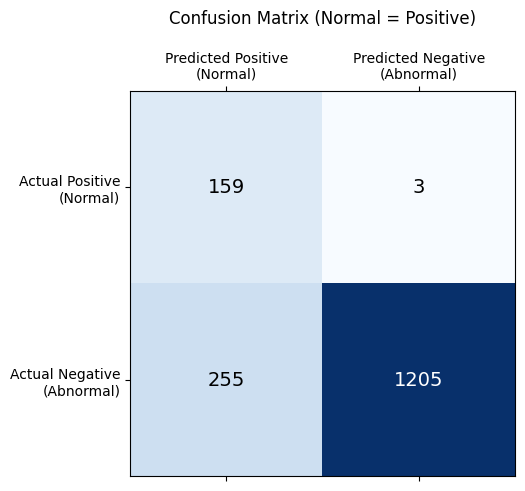

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Confusion matrix 값 (Normal = Positive)
TP = 159
TN = 1205
FP = 255
FN = 3

# Confusion matrix 배열 생성
cm = np.array([[TP, FN],
               [FP, TN]])

fig, ax = plt.subplots(figsize=(5, 5))

# 색상 스케일을 0 ~ 최대값으로 고정
cax = ax.matshow(cm, cmap="Blues", vmin=0, vmax=cm.max())

# 값 표시 (숫자 색을 배경 밝기에 따라 흰색/검정으로 자동 변경)
for (i, j), val in np.ndenumerate(cm):
    color = "white" if val > cm.max() / 2 else "black"
    ax.text(j, i, f"{val}", ha="center", va="center", fontsize=14, color=color)

# 축 라벨 지정
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Predicted Positive\n(Normal)", "Predicted Negative\n(Abnormal)"], fontsize=10)
ax.set_yticklabels(["Actual Positive\n(Normal)", "Actual Negative\n(Abnormal)"], fontsize=10)

plt.title("Confusion Matrix (Normal = Positive)", pad=20)
# plt.colorbar(cax)
plt.show()


In [17]:
import os
import pandas as pd

folder = "/mnt/dataset/osteo/ace_followup/patientA"

file_list = sorted([
    os.path.join(folder, f)
    for f in os.listdir(folder)
    if os.path.isfile(os.path.join(folder, f))
])

df = pd.DataFrame({
    "file_path": file_list,
    "label": 0
})

print(df.head())

                                           file_path  label
0  /mnt/dataset/osteo/ace_followup/patientA/00140...      0
1  /mnt/dataset/osteo/ace_followup/patientA/00140...      0
2  /mnt/dataset/osteo/ace_followup/patientA/00140...      0
3  /mnt/dataset/osteo/ace_followup/patientA/00140...      0
4  /mnt/dataset/osteo/ace_followup/patientA/00140...      0


In [19]:
df.to_csv('/mnt/home/jhpark1/paper_folder/lt-classification/Ansan_Ace.csv',index=False)

In [20]:
import os
import pandas as pd

folder = "/mnt/dataset/osteo/ace_followup/patientB"

file_list = sorted([
    os.path.join(folder, f)
    for f in os.listdir(folder)
    if os.path.isfile(os.path.join(folder, f))
])

df = pd.DataFrame({
    "file_path": file_list,
    "label": 0
})

print(df.head())

                                           file_path  label
0  /mnt/dataset/osteo/ace_followup/patientB/00139...      0
1  /mnt/dataset/osteo/ace_followup/patientB/00139...      0
2  /mnt/dataset/osteo/ace_followup/patientB/00139...      0
3  /mnt/dataset/osteo/ace_followup/patientB/00139...      0
4  /mnt/dataset/osteo/ace_followup/patientB/00139...      0


In [21]:
df.to_csv('/mnt/home/jhpark1/paper_folder/lt-classification/Ansan_Ace_B.csv',index=False)

In [23]:
!pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 42.4 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip


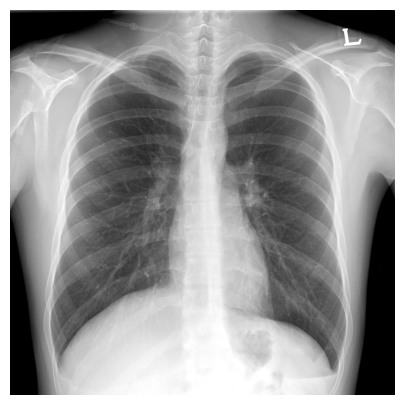

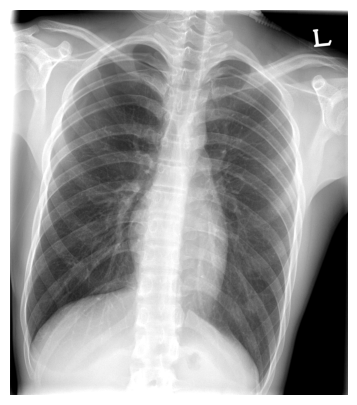

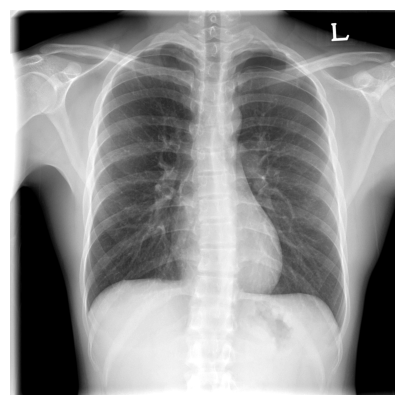

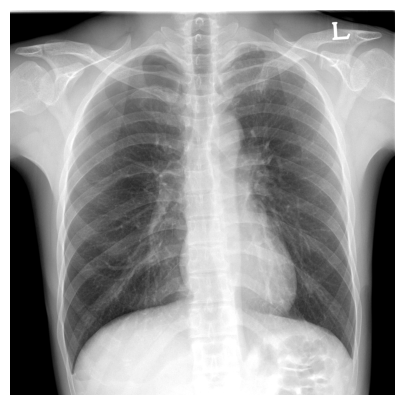

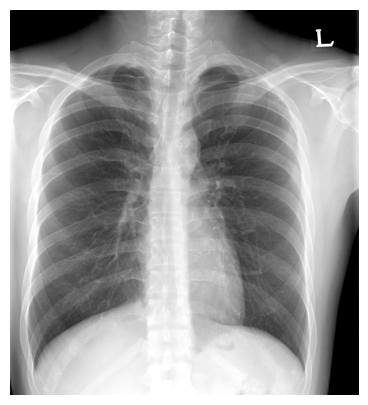

In [34]:
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt
paths = [
    "/mnt/dataset/Normal_Triage_mi2rl/v3/valid/others/pneumothorax/111000271_11Pneumothorax.dcm",
    "/mnt/dataset/Normal_Triage_mi2rl/v3/valid/others/pneumothorax/111001494_11Pneumothorax.dcm",
    "/mnt/dataset/Normal_Triage_mi2rl/v3/valid/others/pneumothorax/111002042_11Pneumothorax.dcm",
    "/mnt/dataset/Normal_Triage_mi2rl/v3/valid/others/pneumothorax/111002182_11Pneumothorax.dcm",
    "/mnt/dataset/Normal_Triage_mi2rl/v3/valid/others/pneumothorax/111003411_11Pneumothorax.dcm",
]

def read_dicom_as_numpy(path):
    img = sitk.ReadImage(path)                # SimpleITK Image
    arr = sitk.GetArrayFromImage(img)         # (z, y, x)
    if arr.ndim == 3:
        z = arr.shape[0] // 2
        arr2d = arr[z]
    else:
        arr2d = arr
    try:
        wc = float(img.GetMetaData("0028|1050"))  # WindowCenter
        ww = float(img.GetMetaData("0028|1051"))  # WindowWidth
        lo = wc - ww / 2.0
        hi = wc + ww / 2.0
    except Exception:
        lo, hi = np.percentile(arr2d, [1, 99])
    arr2d = np.clip(arr2d, lo, hi)
    arr2d = (arr2d - lo) / (hi - lo + 1e-8)
    return arr2d, img

for i, path in enumerate(paths, 1):
    try:
        img2d, itk_img = read_dicom_as_numpy(path)
        plt.figure(figsize=(5, 5))
        plt.imshow(img2d, cmap="gray")
        # plt.title(f"{i}: {path.split('/')[-1]}")
        plt.axis("off")
        plt.show()
    except Exception as e:
        print(f"[ERROR] {path}: {e}")
